In [1]:
from dataclasses import dataclass
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
import tiktoken

In [2]:
print(torch.cuda.is_available()) 
print(torch.cuda.device_count()) 
print(torch.cuda.get_device_name()) 

True
1
NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
""" 
A short description of the dataclasses model:
It provides decorator and functions for automatically adding 
generated special methods such as __init__() and __repr__() to 
user defined classes."""

' \nA short description of the dataclasses model:\nIt provides decorator and functions for automatically adding \ngenerated special methods such as __init__() and __repr__() to \nuser defined classes.'

## **Attention is All you need**
### **Difference in the Transformer of the Paper versus GPT2**

--------------

- 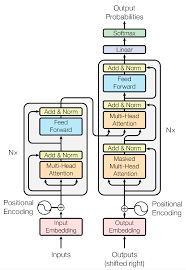
- GPT2 has no encoder; it is a decoder-only architecture.
- GPT2 does not include multihead cross-attention.
- Two main architectural differences:
    - Layer normalization has been reshuffled in the layer ordering.
    - An additional layer normalization was added after the final self-attention block.
    - Pre-normalization architecture
    - 
- [Read the original paper](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)

--------------

Tokens\
  ↓\
Embedding\
  ↓\
Decoder Blocks\
  ↓\
Linear Head\
  ↓\
Next Token Prediction

---------------

- 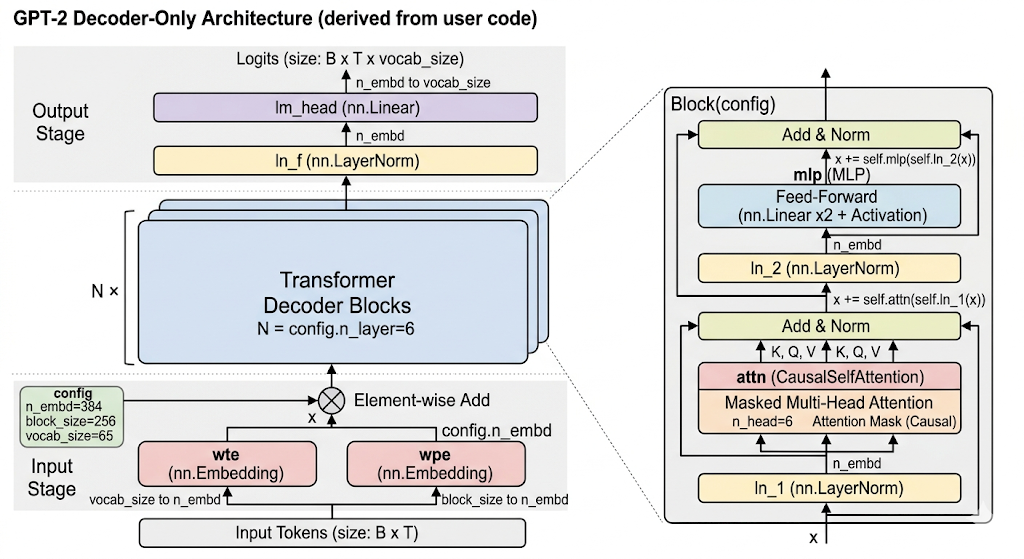
- 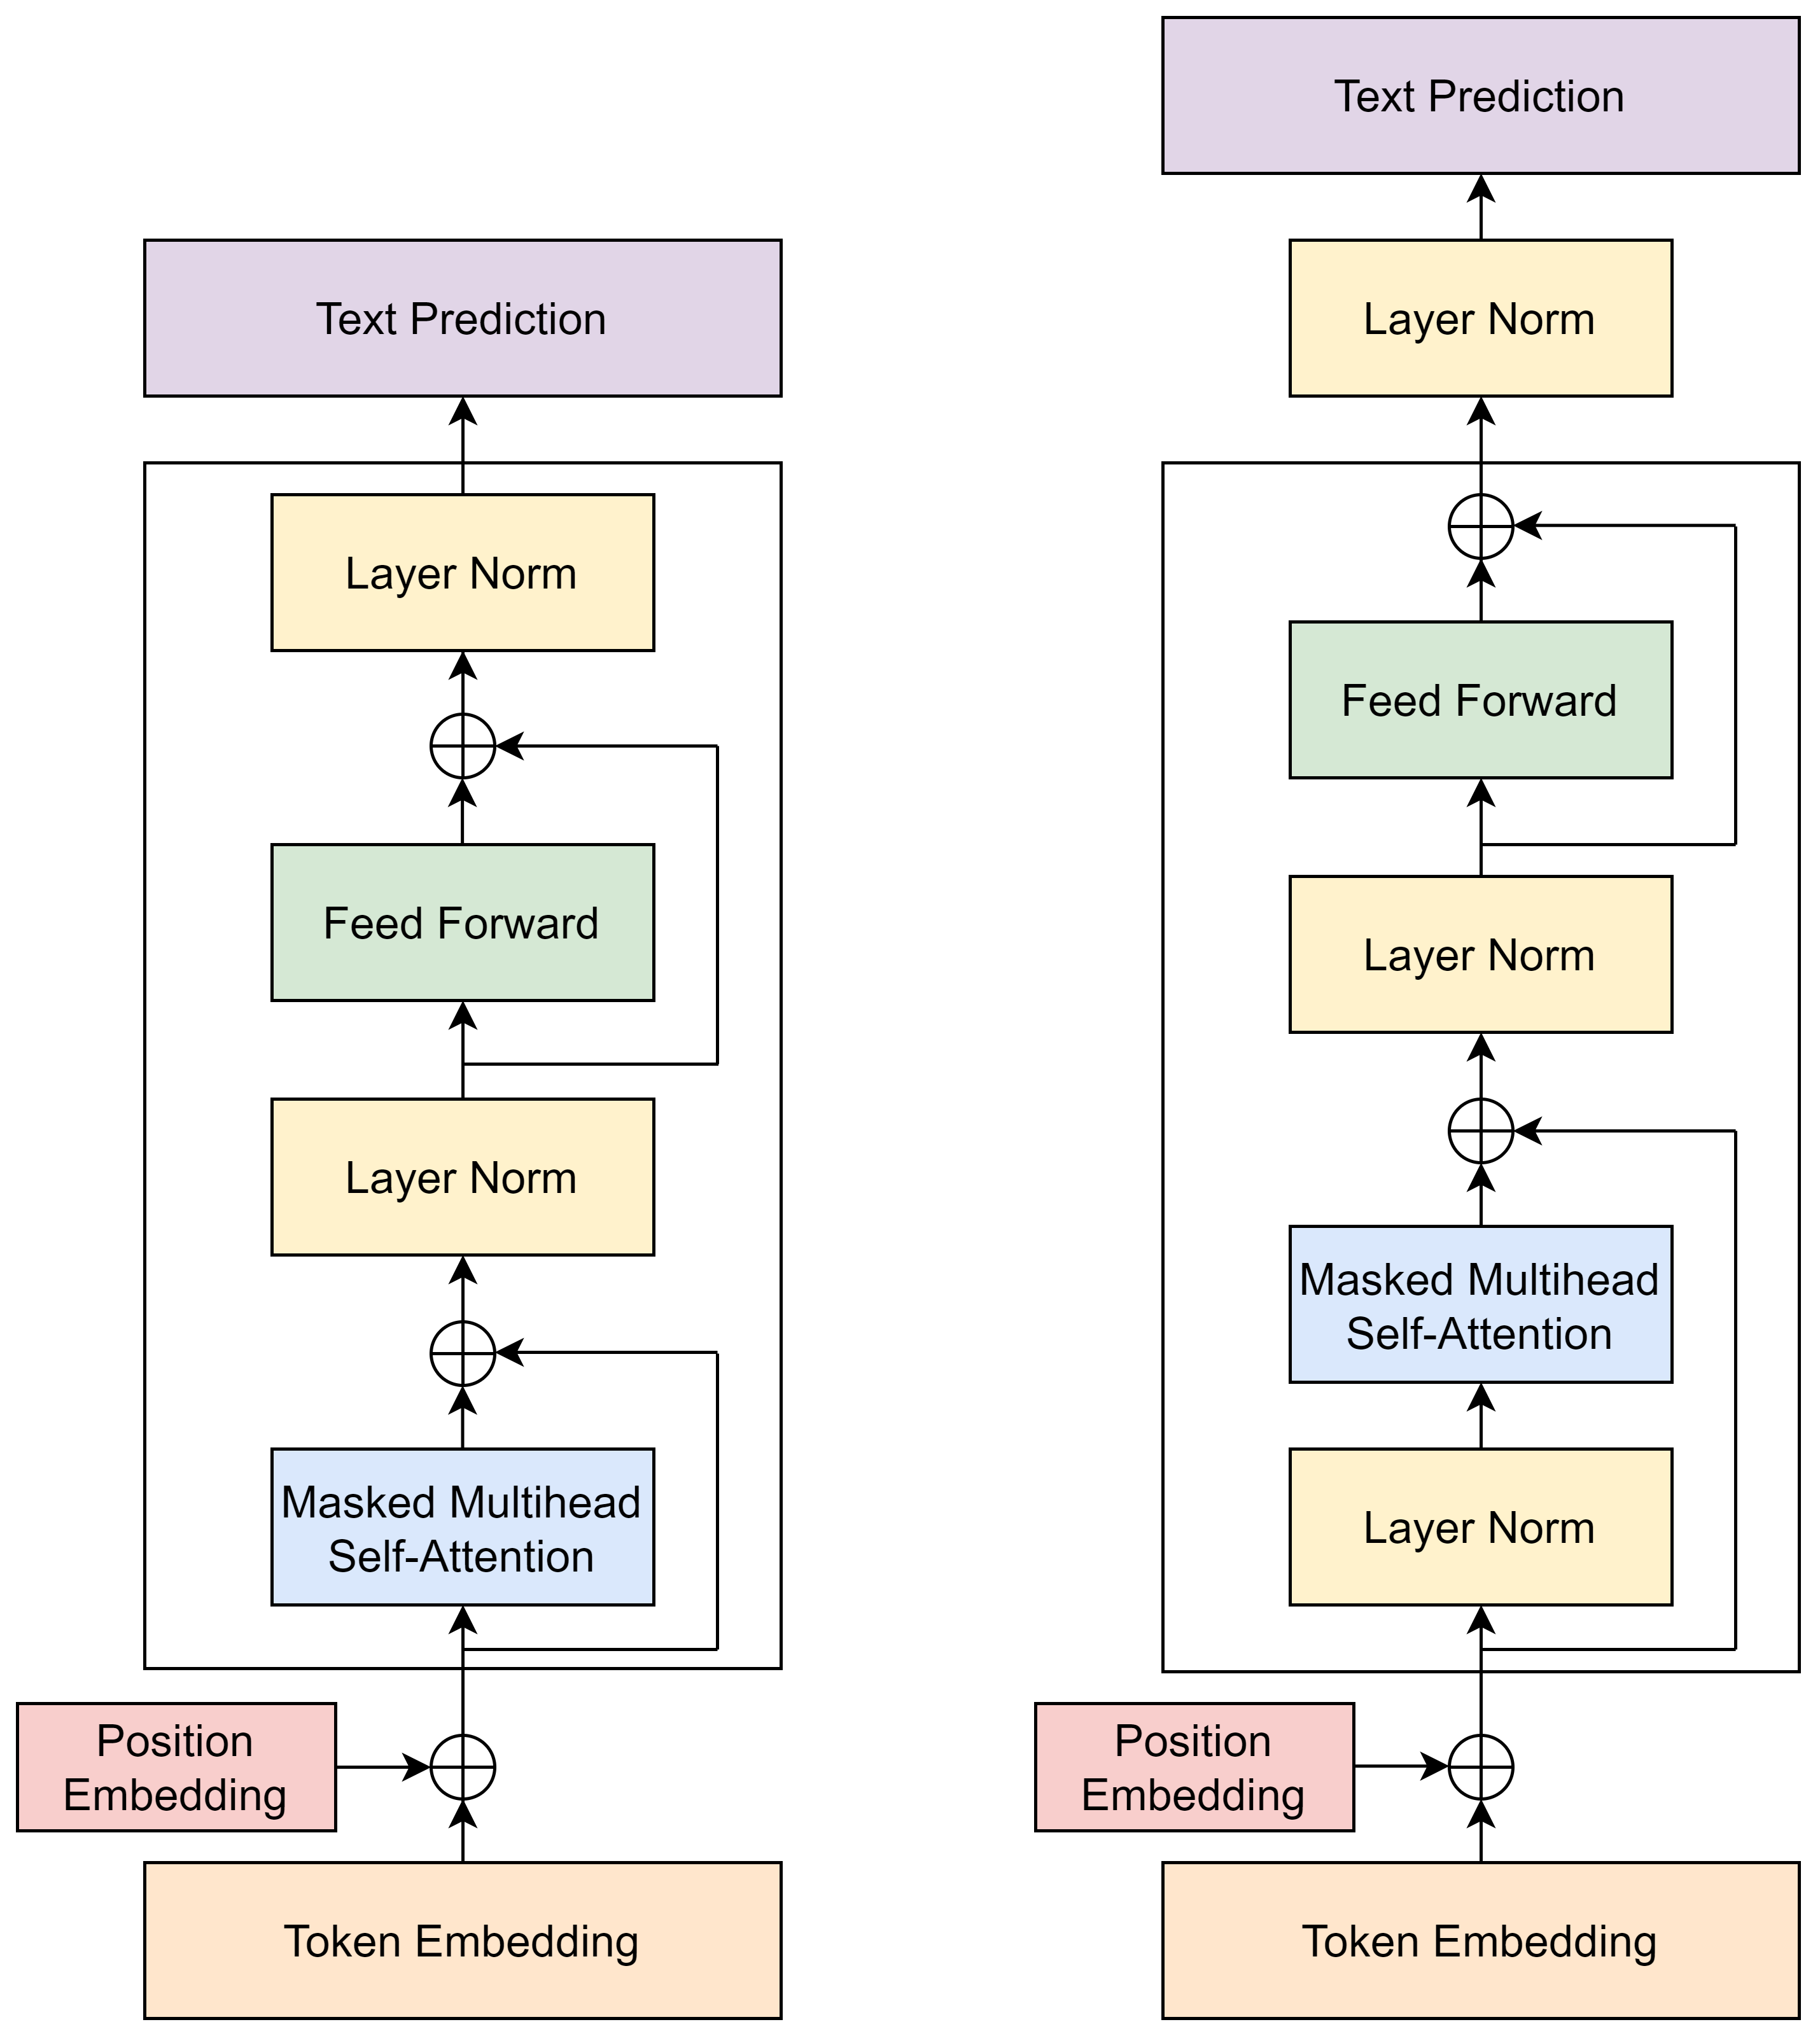
- 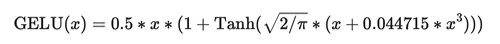



----------------

*There might be bug in our code  [. In
our model, we share the same weight matrix between the two embedding layers and the pre-softmax
linear transformation, similar to](https://arxiv.org/pdf/1706.03762). The concept of weight tying is used. wte i.e isthe input embeeding has the vocab size = 50257 and n_embd = 768. The lm_head has also the smae shape. Insted of learning the embedding matrix and the output matrix we force the embedding to be equal to the ouput matrix. To make sense of this lets take, "cat" has the embedding E_cat, then when predicting the next token we want the hiddent state to score highly against tokens whose embeddings are similar.*



In [4]:
class CausalSelfAttention(nn.Module):
    
    def __init__(self,config):
        super().__init__()
        assert config.n_embd % config.n_head == 0#return assertion error for the unmatched condition
    # key, query, value projectipns for all heads but in a batch
        self.c_attn = nn.Linear(config.n_embd,3*config.n_embd)
        
    #output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
    #regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        #not really a 'bias', more of a mask but follwing the OpenAI/HF naming though
        self.register_buffer("bias",torch.tril(torch.ones(config.block_size,config.block_size)).
                             view(1,1,config.block_size,config.block_size))
    def forward(self,x):
        B,T,C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        
        qkv = self.c_attn(x)
        
        q,k,v = qkv.split(self.n_embd, dim=2)
        k = k.view(B,T, self.n_head,C // self.n_head).transpose(1,2)
        q = q.view(B,T, self.n_head,C // self.n_head).transpose(1,2)
        v = v.view(B,T, self.n_head,C // self.n_head).transpose(1,2)
        
        #attetipn(materializes the large (T,T) matrix for all the queries and keys)
        att = (q @ k.transpose(-2,-1))* (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill (self.bias[:,:,:T,:T] == 0,float('-inf'))
        att = F.softmax(att,dim=-1)
        y = att @ v
        y = y.transpose(1,2).contiguous().view(B,T,C)#re-assemble all heads outputs side by side
        #output projection
        y = self.c_proj(y)
        return y        
        


class MLP(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd,4*config.n_embd)
        self.gelu = nn.GELU(approximate='tanh')#GELU(x) = x.psi(x, psi(x) is the cdg of standard normal distribution
        self.c_proj = nn.Linear(4*config.n_embd,config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
    
    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x


class Block(nn.Module):
    def __init__(self,config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)#multi layer perceptron
        #attention is a communication operation
        #the tokens communicate with each other in attention
        #mlp has no infromation exchange between the tokens
        
    
    def forward(self,x):
        # avoid in-place ops to preserve autograd graph
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x




@dataclass
class GPTConfig:
    block_size:int = 1024 #max sequence length.
    vocab_size:int = 50257 #number of token: 50,000 BPE merges + 256 bytes tokens+ 1>[end of text]
    ''' 
    BPE(Byte pari encoding) builds tokens from frequent subword pattern. eg 
    "un","happi","ness"
    GPT learns about 50,000 common words/subwords,
    256 byte level tokens means emojis, symbols, special texts, curropted text,
    then the 1 end of text to separate training documents.'''
    n_layer: int = 12 #number of layers
    n_head: int = 12 #number of heads
    n_embd: int = 768 #embedding dimension
    
    
#The model  
class GPT(nn.Module):
    
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(
            dict(
                wte = nn.Embedding(config.vocab_size, config.n_embd),#wrapper module output embedding
                wpe = nn.Embedding(config.block_size, config.n_embd),#postion embedding
                h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),#all the blocks
                ln_f = nn.LayerNorm(config.n_embd)#lm head is the new module 
            )
        )
        self.lm_head = nn.Linear(config.n_embd,config.vocab_size,bias=False)
        
        #weight tying
        self.transformer.wte.weight = self.lm_head.weight #copies the data pointer of the lm_head
        # thus we are left with the single tensor
        
        #init params
        self.apply(self._init_weights)
    # mirroring the weight initalization
    ''' 
    _init_weights receives one module at a time
    if the module is the instance of the linear module we initalize
    the weights such that each entry is sampled from N(0,0.0.^2)
    the biases are initalized to zero.
    we do the same for the embedding. 
    '''     
    def _init_weights(self,module):
        std = 0.02
        #reduce weight initalization scale in deep networks to prevantactivations from exploading
        # model is a stack of residal blocks thus each block adds x = x+F(x) thus 
        #the varience grows with layers and activation becomes unstable
        #training becomes noisy or diverges
        #scalign reduces initalization std 
        #varience adds up roughly linearly thus we need to compensate by scaling
        # 2*L is beacuse of the 2 residual addtions from attention path and MLP layer
        if hasattr(module,'NANOGPT_SCALE_INIT'):
            std *= (2*self.config.n_layer) ** -0.5
            
        if isinstance(module,nn.Linear):
            torch.nn.init.normal_(module.weight,mean = 0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
        
        
    #forward function for the model.
        """
        idx contains token id of the shape B,T where
        B is the batch size and T is the sequence length
        idx.size returns the batch size and the token length.
        the assertion is to ensure sequenece fits in the context window.
        Then the torch.arange creates the value from 0 upto the T-1
        Then we get the postion embeddings and the token embeddings from the transformer and add
        then for the each blocks of the tranformer we sent the encoded x 
        then apply the ln_f
        then obtain the logits
        
        """
    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"
        # forward the token and posisition embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)
        # forward the final layernorm and the classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x) # (B, T, vocab_size) ie. (B,T,50257)
        loss = None
        if targets is not None:
            # view here is flattening the # dim tensor, logits, to the 2 dim tensor
            # then the targets are flattening to the 1dim
           loss = F.cross_entropy(logits.view(-1,logits.size(-1)),targets.view(-1)) 
        return logits ,loss#logits is the unnormalized score
    

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        #GPT-2 uses conv1D but we need to use linear thus the conv1D uses (in_features,out_features), linear uses (out_features,in_features)
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

In [5]:
''' 
current position is the pointer where we currently are in the same tokeen,
suppose B=2, T=4
then B*T+1 = 9
then the buf becomes 
the +1 so the targets are shifted by one . 
then we build x and y
the intention of the advance position is to reset the current position
to zero after we reach the end.
The current position pointer is to ensure that 
we go to the next sequence after processing all the sequences in the 
current batch.'''
class DataLoaderLite:
    def __init__(self,B,T):
        self.B = B
        self.T = T
        
        # at init load tokens from disk and store them in the momory
        
        with open('data/input.txt','r') as f:
            text = f.read()
            
        enc = tiktoken.get_encoding('gpt2')
        
        tokens = enc.encode(text)
        
        self.tokens = torch.tensor(tokens)
        print(f"Loaded {len(self.tokens)} tokens")
        print(f"1 epoch =  {len(self.tokens) //  (B*T) } batches")
        
        self.current_position = 0
        
    
    def next_batch(self,device):
        
        B,T = self.B,self.T
        buf = self.tokens[self.current_position: self.current_position+B*T+1]
        buf = buf.to(device=device)
        #inputs
        x = (buf[:-1]).view(B,T)
        #targets
        y = (buf[1:]).view(B,T)
        
        #advance the position in the tensor
        self.current_position += B * T
        if self.current_position + (B*T+1) > len(self.tokens):
            self.current_position = 0
        return x,y 
        

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

import time
torch.manual_seed(1337)
train_loader = DataLoaderLite(B=4,T=1024)

# torch.set_float32_matmul_precision('high')
model = GPT(GPTConfig())

model.to(device=device)

optimizer = torch.optim.AdamW(model.parameters(),lr = 3e-4)
for i in range(50):
    t0 = time.time()
    x,y = train_loader.next_batch(device=device)
    optimizer.zero_grad()#starting with the zero gradient
    logits,loss = model(x,y)
    loss.backward()
    optimizer.step()#updating the parameters
    
    torch.cuda.synchronize()  # wait for all CUDA kernels on the current device to finish before continuing
    t1 = time.time()
    dt = (t1-t0) * 1000 # time difference in milliseconds
    tokesn_per_sec = (train_loader.B * train_loader.T) / (t1-t0)
    print(f"step {i}, loss : {loss.item()}, dt : {dt:.2f}ms, tok/sec :{tokesn_per_sec}")
    

Loaded 338025 tokens
1 epoch =  82 batches
step 0, loss : 10.928552627563477, dt : 3608.55ms, tok/sec :1135.0829855050517
step 1, loss : 9.525257110595703, dt : 3624.26ms, tok/sec :1130.1613876171918
step 2, loss : 8.986087799072266, dt : 3384.00ms, tok/sec :1210.4027215245835


In [ ]:
logits.dtype #each of the weights take the flaoting representation
# but for the gpt we donot need that much precision

torch.float32

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

import time
torch.manual_seed(1337)
train_loader = DataLoaderLite(B=4,T=1024)

torch.set_float32_matmul_precision('high')
model = GPT(GPTConfig())
# model = torch.compile(model=model) use if linux avialable or triton works

model = torch.compile(model, backend="inductor", mode="reduce-overhead")

model.to(device=device)

optimizer = torch.optim.AdamW(model.parameters(),lr = 3e-4)
for i in range(50):
    t0 = time.time()
    x,y = train_loader.next_batch(device=device)
    optimizer.zero_grad()#starting with the zero gradient
    with torch.autocast(device_type=device, dtype=torch.bfloat16): 
        logits,loss = model(x,y)
    loss.backward()
    optimizer.step()#updating the parameters
    
    torch.cuda.synchronize()  # wait for all CUDA kernels on the current device to finish before continuing
    t1 = time.time()
    dt = (t1-t0) * 1000 # time difference in milliseconds
    tokesn_per_sec = (train_loader.B * train_loader.T) / (t1-t0)
    print(f"step {i}, loss : {loss.item()}, dt : {dt:.2f}ms, tok/sec :{tokesn_per_sec}")
    

Loaded 338025 tokens
1 epoch =  82 batches


InductorError: FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Acer\\AppData\\Roaming\\Python\\Python312\\site-packages\\triton\\backends\\nvidia\\driver.c'

Set TORCHDYNAMO_VERBOSE=1 for the internal stack trace (please do this especially if you're reporting a bug to PyTorch). For even more developer context, set TORCH_LOGS="+dynamo"
